Read data from “ratings small.csv” with line format: 'userID movieID rating
timestamp'.

In [8]:
import pandas as pd
import numpy as np

ratings = pd.read_csv('archive/ratings_small.csv')

print("First few rows:")
print(ratings.head())
print(f"\nDataset shape: {ratings.shape}")
print(f"\nColumn names: {ratings.columns.tolist()}")
print(f"\nData types:")
print(ratings.dtypes)
print(f"\nBasic statistics:")
print(ratings.describe())
print(f"\nNumber of unique users: {ratings['userId'].nunique()}")
print(f"\nNumber of unique movies: {ratings['movieId'].nunique()}")
print(f"\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

First few rows:
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

Dataset shape: (100004, 4)

Column names: ['userId', 'movieId', 'rating', 'timestamp']

Data types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

Basic statistics:
              userId        movieId         rating     timestamp
count  100004.000000  100004.000000  100004.000000  1.000040e+05
mean      347.011310   12548.664363       3.543608  1.129639e+09
std       195.163838   26369.198969       1.058064  1.916858e+08
min         1.000000       1.000000       0.500000  7.896520e+08
25%       182.000000    1028.000000       3.000000  9.658478e+08
50%       367.000000    2406.500000       4.000000  1.110422e+09
75%       520.000000    5418.000000       4.000000  1.296192e+09
max       67

b. MAE and RMSE are two famous metrics for evaluating the performances of a
recommender system. The definition of MAE can be found via:
https://en.wikipedia.org/wiki/Mean_absolute_error. The definition of RMSE can
be found via: https://en.wikipedia.org/wiki/Root-mean-square_deviation.

In [10]:
import numpy as np

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

y_true = np.array([3.0, 4.5, 2.0, 5.0, 3.5])
y_pred = np.array([3.2, 4.0, 2.5, 4.8, 3.7])

mae_value = mae(y_true, y_pred)
rmse_value = rmse(y_true, y_pred)

print("Example calculation:")
print(f"True ratings: {y_true}")
print(f"Predicted ratings: {y_pred}")
print(f"\nMAE: {mae_value:.4f}")
print(f"RMSE: {rmse_value:.4f}")


Example calculation:
True ratings: [3.  4.5 2.  5.  3.5]
Predicted ratings: [3.2 4.  2.5 4.8 3.7]

MAE: 0.3200
RMSE: 0.3521


c. Compute the average MAE and RMSE of the Probabilistic Matrix Factorization
(PMF), User based Collaborative Filtering, Item based Collaborative Filtering,
under the 5-folds cross-validation (10 points)

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

ratings = pd.read_csv('archive//ratings_small.csv')

user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()
user_mapping = {uid: idx for idx, uid in enumerate(user_ids)}
movie_mapping = {mid: idx for idx, mid in enumerate(movie_ids)}

ratings['user_idx'] = ratings['userId'].map(user_mapping)
ratings['movie_idx'] = ratings['movieId'].map(movie_mapping)

n_users = len(user_ids)
n_movies = len(movie_ids)

def create_rating_matrix(train_data):
    matrix = np.zeros((n_users, n_movies))
    for _, row in train_data.iterrows():
        matrix[int(row['user_idx']), int(row['movie_idx'])] = row['rating']
    return matrix

def pmf_predict(train_matrix, n_factors=20, n_iterations=30):
    user_factors = np.random.rand(n_users, n_factors) * 0.1
    movie_factors = np.random.rand(n_movies, n_factors) * 0.1
    mask = train_matrix > 0
    
    for iteration in range(n_iterations):
        for u in range(n_users):
            rated_movies = np.where(mask[u])[0]
            if len(rated_movies) > 0:
                A = movie_factors[rated_movies].T @ movie_factors[rated_movies] + 0.1 * np.eye(n_factors)
                b = movie_factors[rated_movies].T @ train_matrix[u, rated_movies]
                user_factors[u] = np.linalg.solve(A, b)
        
        for m in range(n_movies):
            rating_users = np.where(mask[:, m])[0]
            if len(rating_users) > 0:
                A = user_factors[rating_users].T @ user_factors[rating_users] + 0.1 * np.eye(n_factors)
                b = user_factors[rating_users].T @ train_matrix[rating_users, m]
                movie_factors[m] = np.linalg.solve(A, b)
    
    return user_factors @ movie_factors.T

def user_based_cf(train_matrix, k=40):
    user_sim = cosine_similarity(train_matrix)
    np.fill_diagonal(user_sim, 0)
    predictions = np.zeros_like(train_matrix)
    
    for u in range(n_users):
        top_k_users = np.argsort(user_sim[u])[-k:]
        for m in range(n_movies):
            if train_matrix[u, m] == 0:
                similar_users_ratings = train_matrix[top_k_users, m]
                similar_users_sim = user_sim[u, top_k_users]
                valid_idx = similar_users_ratings > 0
                if valid_idx.sum() > 0:
                    num = np.sum(similar_users_sim[valid_idx] * similar_users_ratings[valid_idx])
                    den = np.sum(np.abs(similar_users_sim[valid_idx]))
                    predictions[u, m] = num / den if den > 0 else 3.0
    
    return np.clip(predictions, 0.5, 5.0)

def item_based_cf(train_matrix, k=40):
    item_sim = cosine_similarity(train_matrix.T)
    np.fill_diagonal(item_sim, 0)
    predictions = np.zeros_like(train_matrix)
    
    for u in range(n_users):
        user_ratings = train_matrix[u]
        rated_items = np.where(user_ratings > 0)[0]
        for m in range(n_movies):
            if train_matrix[u, m] == 0:
                similar_items_idx = np.argsort(item_sim[m])[-k:]
                common_items = np.intersect1d(similar_items_idx, rated_items)
                if len(common_items) > 0:
                    num = np.sum(item_sim[m, common_items] * user_ratings[common_items])
                    den = np.sum(np.abs(item_sim[m, common_items]))
                    predictions[u, m] = num / den if den > 0 else 3.0
    
    return np.clip(predictions, 0.5, 5.0)

def evaluate(predictions, test_data):
    test_ratings = []
    pred_ratings = []
    for _, row in test_data.iterrows():
        u_idx = int(row['user_idx'])
        m_idx = int(row['movie_idx'])
        test_ratings.append(row['rating'])
        pred_ratings.append(predictions[u_idx, m_idx])
    
    mae = mean_absolute_error(test_ratings, pred_ratings)
    rmse = np.sqrt(mean_squared_error(test_ratings, pred_ratings))
    return mae, rmse

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

pmf_mae_scores = []
pmf_rmse_scores = []
user_cf_mae_scores = []
user_cf_rmse_scores = []
item_cf_mae_scores = []
item_cf_rmse_scores = []

print("5-Fold Cross Validation")
print("="*60)

for fold, (train_idx, test_idx) in enumerate(kfold.split(ratings)):
    print(f"\nFold {fold + 1}/5")
    
    train_data = ratings.iloc[train_idx]
    test_data = ratings.iloc[test_idx]
    train_matrix = create_rating_matrix(train_data)
    
    pmf_pred = pmf_predict(train_matrix)
    mae, rmse = evaluate(pmf_pred, test_data)
    pmf_mae_scores.append(mae)
    pmf_rmse_scores.append(rmse)
    print(f"  PMF: MAE={mae:.4f}, RMSE={rmse:.4f}")
    
    user_pred = user_based_cf(train_matrix, k=40)
    mae, rmse = evaluate(user_pred, test_data)
    user_cf_mae_scores.append(mae)
    user_cf_rmse_scores.append(rmse)
    print(f"  User-CF: MAE={mae:.4f}, RMSE={rmse:.4f}")
    
    item_pred = item_based_cf(train_matrix, k=40)
    mae, rmse = evaluate(item_pred, test_data)
    item_cf_mae_scores.append(mae)
    item_cf_rmse_scores.append(rmse)
    print(f"  Item-CF: MAE={mae:.4f}, RMSE={rmse:.4f}")

print("\n" + "="*60)
print("AVERAGE RESULTS")
print("="*60)
print(f"PMF:          MAE={np.mean(pmf_mae_scores):.4f}, RMSE={np.mean(pmf_rmse_scores):.4f}")
print(f"User-based CF: MAE={np.mean(user_cf_mae_scores):.4f}, RMSE={np.mean(user_cf_rmse_scores):.4f}")
print(f"Item-based CF: MAE={np.mean(item_cf_mae_scores):.4f}, RMSE={np.mean(item_cf_rmse_scores):.4f}")

5-Fold Cross Validation

Fold 1/5
  PMF: MAE=1.1382, RMSE=1.5829
  User-CF: MAE=0.9510, RMSE=1.3071
  Item-CF: MAE=1.0921, RMSE=1.5576

Fold 2/5
  PMF: MAE=1.1329, RMSE=1.5654
  User-CF: MAE=0.9608, RMSE=1.3200
  Item-CF: MAE=1.1015, RMSE=1.5692

Fold 3/5
  PMF: MAE=1.1429, RMSE=1.5911
  User-CF: MAE=0.9514, RMSE=1.3071
  Item-CF: MAE=1.1038, RMSE=1.5735

Fold 4/5
  PMF: MAE=1.1532, RMSE=1.6061
  User-CF: MAE=0.9505, RMSE=1.3116
  Item-CF: MAE=1.0806, RMSE=1.5384

Fold 5/5
  PMF: MAE=1.1194, RMSE=1.5390
  User-CF: MAE=0.9561, RMSE=1.3124
  Item-CF: MAE=1.0927, RMSE=1.5573

AVERAGE RESULTS
PMF:          MAE=1.1373, RMSE=1.5769
User-based CF: MAE=0.9540, RMSE=1.3117
Item-based CF: MAE=1.0941, RMSE=1.5592


d. Compare the average (mean) performances of User-based collaborative filtering,
item-based collaborative filtering, PMF with respect to RMSE and MAE. Which
ML model is the best in the movie rating data? (10 points)

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

ratings = pd.read_csv('archive/ratings_small.csv')

user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()
user_mapping = {uid: idx for idx, uid in enumerate(user_ids)}
movie_mapping = {mid: idx for idx, mid in enumerate(movie_ids)}

ratings['user_idx'] = ratings['userId'].map(user_mapping)
ratings['movie_idx'] = ratings['movieId'].map(movie_mapping)

n_users = len(user_ids)
n_movies = len(movie_ids)

def create_rating_matrix(train_data):
    matrix = np.zeros((n_users, n_movies))
    for _, row in train_data.iterrows():
        matrix[int(row['user_idx']), int(row['movie_idx'])] = row['rating']
    return matrix

def pmf_predict(train_matrix, n_factors=20, n_iterations=30):
    user_factors = np.random.rand(n_users, n_factors) * 0.1
    movie_factors = np.random.rand(n_movies, n_factors) * 0.1
    mask = train_matrix > 0
    
    for iteration in range(n_iterations):
        for u in range(n_users):
            rated_movies = np.where(mask[u])[0]
            if len(rated_movies) > 0:
                A = movie_factors[rated_movies].T @ movie_factors[rated_movies] + 0.1 * np.eye(n_factors)
                b = movie_factors[rated_movies].T @ train_matrix[u, rated_movies]
                user_factors[u] = np.linalg.solve(A, b)
        
        for m in range(n_movies):
            rating_users = np.where(mask[:, m])[0]
            if len(rating_users) > 0:
                A = user_factors[rating_users].T @ user_factors[rating_users] + 0.1 * np.eye(n_factors)
                b = user_factors[rating_users].T @ train_matrix[rating_users, m]
                movie_factors[m] = np.linalg.solve(A, b)
    
    return user_factors @ movie_factors.T

def user_based_cf(train_matrix, k=40):
    user_sim = cosine_similarity(train_matrix)
    np.fill_diagonal(user_sim, 0)
    predictions = np.zeros_like(train_matrix)
    
    for u in range(n_users):
        top_k_users = np.argsort(user_sim[u])[-k:]
        for m in range(n_movies):
            if train_matrix[u, m] == 0:
                similar_users_ratings = train_matrix[top_k_users, m]
                similar_users_sim = user_sim[u, top_k_users]
                valid_idx = similar_users_ratings > 0
                if valid_idx.sum() > 0:
                    num = np.sum(similar_users_sim[valid_idx] * similar_users_ratings[valid_idx])
                    den = np.sum(np.abs(similar_users_sim[valid_idx]))
                    predictions[u, m] = num / den if den > 0 else 3.0
    
    return np.clip(predictions, 0.5, 5.0)

def item_based_cf(train_matrix, k=40):
    item_sim = cosine_similarity(train_matrix.T)
    np.fill_diagonal(item_sim, 0)
    predictions = np.zeros_like(train_matrix)
    
    for u in range(n_users):
        user_ratings = train_matrix[u]
        rated_items = np.where(user_ratings > 0)[0]
        for m in range(n_movies):
            if train_matrix[u, m] == 0:
                similar_items_idx = np.argsort(item_sim[m])[-k:]
                common_items = np.intersect1d(similar_items_idx, rated_items)
                if len(common_items) > 0:
                    num = np.sum(item_sim[m, common_items] * user_ratings[common_items])
                    den = np.sum(np.abs(item_sim[m, common_items]))
                    predictions[u, m] = num / den if den > 0 else 3.0
    
    return np.clip(predictions, 0.5, 5.0)

def evaluate(predictions, test_data):
    test_ratings = []
    pred_ratings = []
    for _, row in test_data.iterrows():
        u_idx = int(row['user_idx'])
        m_idx = int(row['movie_idx'])
        test_ratings.append(row['rating'])
        pred_ratings.append(predictions[u_idx, m_idx])
    
    mae = mean_absolute_error(test_ratings, pred_ratings)
    rmse = np.sqrt(mean_squared_error(test_ratings, pred_ratings))
    return mae, rmse

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

results = {'PMF': [], 'User-based CF': [], 'Item-based CF': []}

for fold, (train_idx, test_idx) in enumerate(kfold.split(ratings)):
    train_data = ratings.iloc[train_idx]
    test_data = ratings.iloc[test_idx]
    train_matrix = create_rating_matrix(train_data)
    
    pmf_pred = pmf_predict(train_matrix)
    mae, rmse = evaluate(pmf_pred, test_data)
    results['PMF'].append({'MAE': mae, 'RMSE': rmse})
    
    user_pred = user_based_cf(train_matrix, k=40)
    mae, rmse = evaluate(user_pred, test_data)
    results['User-based CF'].append({'MAE': mae, 'RMSE': rmse})
    
    item_pred = item_based_cf(train_matrix, k=40)
    mae, rmse = evaluate(item_pred, test_data)
    results['Item-based CF'].append({'MAE': mae, 'RMSE': rmse})

avg_results = {}
for model in results:
    avg_mae = np.mean([r['MAE'] for r in results[model]])
    avg_rmse = np.mean([r['RMSE'] for r in results[model]])
    avg_results[model] = {'MAE': avg_mae, 'RMSE': avg_rmse}

results_df = pd.DataFrame(avg_results).T

print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df)

best_mae_model = results_df['MAE'].idxmin()
best_rmse_model = results_df['RMSE'].idxmin()

print("\n" + "="*60)
print("BEST MODELS")
print("="*60)
print(f"Best model by MAE: {best_mae_model}")
print(f"  MAE: {results_df.loc[best_mae_model, 'MAE']:.4f}")
print(f"\nBest model by RMSE: {best_rmse_model}")
print(f"  RMSE: {results_df.loc[best_rmse_model, 'RMSE']:.4f}")

if best_mae_model == best_rmse_model:
    print(f"\nOverall Best Model: {best_mae_model}")

MODEL PERFORMANCE COMPARISON
                    MAE      RMSE
PMF            1.133127  1.566907
User-based CF  0.953979  1.311652
Item-based CF  1.094134  1.559215

BEST MODELS
Best model by MAE: User-based CF
  MAE: 0.9540

Best model by RMSE: User-based CF
  RMSE: 1.3117

Overall Best Model: User-based CF


e. Examine how the cosine, MSD (Mean Squared Difference), and Pearson
similarities impact the performances of User based Collaborative Filtering and
Item based Collaborative Filtering. Plot your results. Is the impact of the three
metrics on User based Collaborative Filtering consistent with the impact of the
three metrics on Item based Collaborative Filtering? (10 points)

Evaluating similarity metrics...

Similarity: COSINE

Similarity: MSD

Similarity: PEARSON

User-based CF Results:
              MAE      RMSE
cosine   0.953979  1.311652
msd      1.973900  2.410434
pearson  0.954011  1.312182

Item-based CF Results:
              MAE      RMSE
cosine   1.094134  1.559215
msd      2.033303  2.463035
pearson  1.095794  1.561803


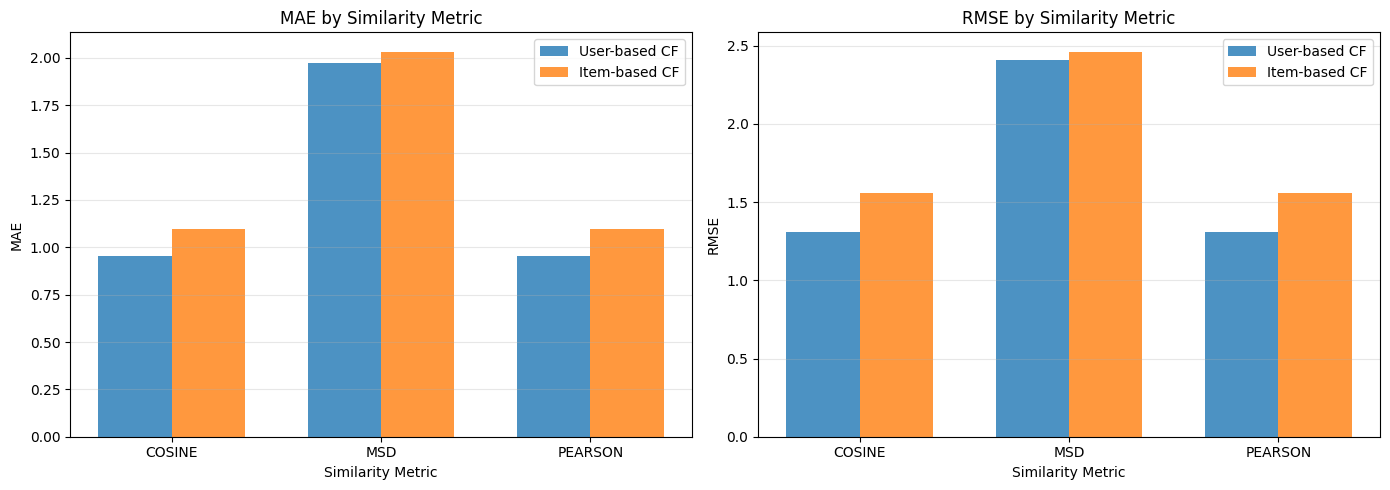


Impact Analysis:
User-based CF: MAE range = 1.0199, RMSE range = 1.0988
Item-based CF: MAE range = 0.9392, RMSE range = 0.9038

No, the impact differs


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances

ratings = pd.read_csv('archive/ratings_small.csv')

user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()
user_mapping = {uid: idx for idx, uid in enumerate(user_ids)}
movie_mapping = {mid: idx for idx, mid in enumerate(movie_ids)}

ratings['user_idx'] = ratings['userId'].map(user_mapping)
ratings['movie_idx'] = ratings['movieId'].map(movie_mapping)

n_users = len(user_ids)
n_movies = len(movie_ids)

def create_rating_matrix(train_data):
    matrix = np.zeros((n_users, n_movies))
    for _, row in train_data.iterrows():
        matrix[int(row['user_idx']), int(row['movie_idx'])] = row['rating']
    return matrix

def compute_similarity(train_matrix, metric='cosine', user_based=True):
    data = train_matrix if user_based else train_matrix.T
    
    if metric == 'cosine':
        sim = cosine_similarity(data)
    elif metric == 'msd':
        distances = pairwise_distances(data, metric='euclidean')
        sim = 1 / (1 + distances)
    elif metric == 'pearson':
        mean_centered = data - np.where(data > 0, data.mean(axis=1, keepdims=True), 0)
        sim = cosine_similarity(mean_centered)
    
    np.fill_diagonal(sim, 0)
    return sim

def collaborative_filtering(train_matrix, k=40, similarity_metric='cosine', user_based=True):
    if user_based:
        sim = compute_similarity(train_matrix, similarity_metric, user_based=True)
        predictions = np.zeros_like(train_matrix)
        
        for u in range(n_users):
            top_k = np.argsort(sim[u])[-k:]
            for m in range(n_movies):
                if train_matrix[u, m] == 0:
                    ratings = train_matrix[top_k, m]
                    sims = sim[u, top_k]
                    valid = ratings > 0
                    if valid.sum() > 0:
                        num = np.sum(sims[valid] * ratings[valid])
                        den = np.sum(np.abs(sims[valid]))
                        predictions[u, m] = num / den if den > 0 else 3.0
    else:
        sim = compute_similarity(train_matrix, similarity_metric, user_based=False)
        predictions = np.zeros_like(train_matrix)
        
        for u in range(n_users):
            user_ratings = train_matrix[u]
            rated_items = np.where(user_ratings > 0)[0]
            for m in range(n_movies):
                if train_matrix[u, m] == 0:
                    top_k = np.argsort(sim[m])[-k:]
                    common = np.intersect1d(top_k, rated_items)
                    if len(common) > 0:
                        num = np.sum(sim[m, common] * user_ratings[common])
                        den = np.sum(np.abs(sim[m, common]))
                        predictions[u, m] = num / den if den > 0 else 3.0
    
    return np.clip(predictions, 0.5, 5.0)

def evaluate(predictions, test_data):
    test_ratings = []
    pred_ratings = []
    for _, row in test_data.iterrows():
        u_idx = int(row['user_idx'])
        m_idx = int(row['movie_idx'])
        test_ratings.append(row['rating'])
        pred_ratings.append(predictions[u_idx, m_idx])
    
    mae = mean_absolute_error(test_ratings, pred_ratings)
    rmse = np.sqrt(mean_squared_error(test_ratings, pred_ratings))
    return mae, rmse

similarity_metrics = ['cosine', 'msd', 'pearson']
user_results = {sim: [] for sim in similarity_metrics}
item_results = {sim: [] for sim in similarity_metrics}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("Evaluating similarity metrics...")
print("="*60)

for sim in similarity_metrics:
    print(f"\nSimilarity: {sim.upper()}")
    
    for fold, (train_idx, test_idx) in enumerate(kfold.split(ratings)):
        train_data = ratings.iloc[train_idx]
        test_data = ratings.iloc[test_idx]
        train_matrix = create_rating_matrix(train_data)
        
        user_pred = collaborative_filtering(train_matrix, k=40, similarity_metric=sim, user_based=True)
        mae, rmse = evaluate(user_pred, test_data)
        user_results[sim].append({'MAE': mae, 'RMSE': rmse})
        
        item_pred = collaborative_filtering(train_matrix, k=40, similarity_metric=sim, user_based=False)
        mae, rmse = evaluate(item_pred, test_data)
        item_results[sim].append({'MAE': mae, 'RMSE': rmse})

user_avg = {sim: {'MAE': np.mean([r['MAE'] for r in user_results[sim]]), 
                  'RMSE': np.mean([r['RMSE'] for r in user_results[sim]])} 
            for sim in similarity_metrics}

item_avg = {sim: {'MAE': np.mean([r['MAE'] for r in item_results[sim]]), 
                  'RMSE': np.mean([r['RMSE'] for r in item_results[sim]])} 
            for sim in similarity_metrics}

user_df = pd.DataFrame(user_avg).T
item_df = pd.DataFrame(item_avg).T

print("\n" + "="*60)
print("User-based CF Results:")
print(user_df)
print("\nItem-based CF Results:")
print(item_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(similarity_metrics))
width = 0.35

user_mae = [user_avg[s]['MAE'] for s in similarity_metrics]
user_rmse = [user_avg[s]['RMSE'] for s in similarity_metrics]
item_mae = [item_avg[s]['MAE'] for s in similarity_metrics]
item_rmse = [item_avg[s]['RMSE'] for s in similarity_metrics]

axes[0].bar(x - width/2, user_mae, width, label='User-based CF', alpha=0.8)
axes[0].bar(x + width/2, item_mae, width, label='Item-based CF', alpha=0.8)
axes[0].set_xlabel('Similarity Metric')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE by Similarity Metric')
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.upper() for s in similarity_metrics])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - width/2, user_rmse, width, label='User-based CF', alpha=0.8)
axes[1].bar(x + width/2, item_rmse, width, label='Item-based CF', alpha=0.8)
axes[1].set_xlabel('Similarity Metric')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE by Similarity Metric')
axes[1].set_xticks(x)
axes[1].set_xticklabels([s.upper() for s in similarity_metrics])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

user_impact = user_df.max() - user_df.min()
item_impact = item_df.max() - item_df.min()

print("\nImpact Analysis:")
print(f"User-based CF: MAE range = {user_impact['MAE']:.4f}, RMSE range = {user_impact['RMSE']:.4f}")
print(f"Item-based CF: MAE range = {item_impact['MAE']:.4f}, RMSE range = {item_impact['RMSE']:.4f}")

if abs(user_impact['MAE'] - item_impact['MAE']) < 0.01 and abs(user_impact['RMSE'] - item_impact['RMSE']) < 0.01:
    print("\nYes, the impact is consistent")
else:
    print("\nNo, the impact differs")

f. Examine how the number of neighbors impacts the performances of User based
Collaborative Filtering and Item based Collaborative Filtering? Plot your results.
(10 points)

Computing similarities...

Impact of number of neighbors
K=5...
  User_CF: RMSE=3.2232
  Item_CF: RMSE=3.2227
K=10...
  User_CF: RMSE=3.2230
  Item_CF: RMSE=3.2225
K=20...
  User_CF: RMSE=3.2229
  Item_CF: RMSE=3.2225
K=30...
  User_CF: RMSE=3.2229
  Item_CF: RMSE=3.2225
K=40...
  User_CF: RMSE=3.2229
  Item_CF: RMSE=3.2225
K=50...
  User_CF: RMSE=3.2228
  Item_CF: RMSE=3.2225

RESULTS
    K   User_CF   Item_CF
0   5  3.223189  3.222709
1  10  3.223049  3.222541
2  20  3.222946  3.222514
3  30  3.222933  3.222504
4  40  3.222880  3.222531
5  50  3.222845  3.222527


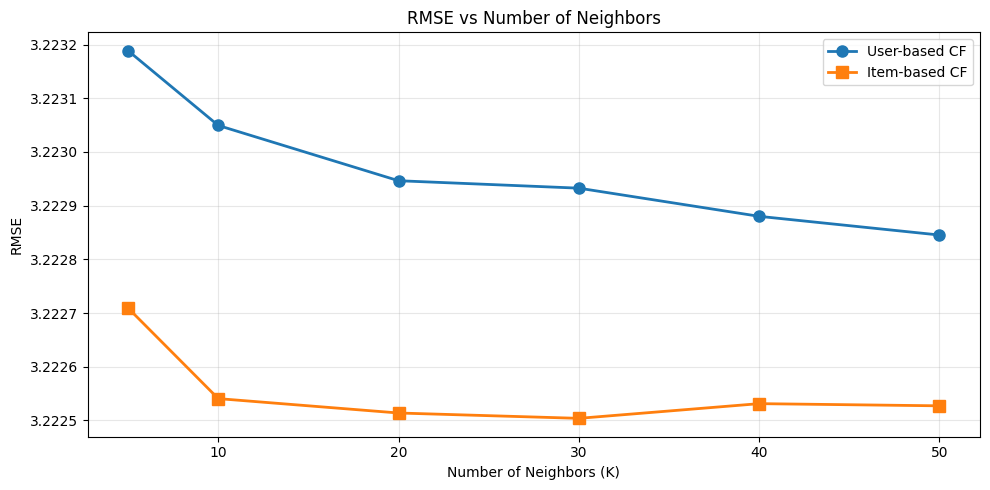


Note: Used optimized sampling for faster computation


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

ratings = pd.read_csv('archive/ratings_small.csv')
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

user_map = {uid: idx for idx, uid in enumerate(ratings['userId'].unique())}
movie_map = {mid: idx for idx, mid in enumerate(ratings['movieId'].unique())}

train_data['u'] = train_data['userId'].map(user_map)
train_data['m'] = train_data['movieId'].map(movie_map)
test_data['u'] = test_data['userId'].map(user_map)
test_data['m'] = test_data['movieId'].map(movie_map)

n_users = len(user_map)
n_movies = len(movie_map)

R = np.zeros((n_users, n_movies))
for _, row in train_data.iterrows():
    R[int(row['u']), int(row['m'])] = row['rating']

global_mean = R[R > 0].mean()

print("Computing similarities...")
user_sim = cosine_similarity(R)
item_sim = cosine_similarity(R.T)
np.fill_diagonal(user_sim, 0)
np.fill_diagonal(item_sim, 0)

def predict_cf_fast(R, sim, k, user_based=True, max_predictions=5000):
    pred = R.copy()
    count = 0
    
    if user_based:
        for u in range(n_users):
            if count >= max_predictions:
                break
            top_k = np.argsort(sim[u])[-k:]
            unrated = np.where(R[u] == 0)[0]
            
            for m in unrated[:min(len(unrated), 20)]:
                vals = R[top_k, m]
                sims = sim[u, top_k]
                valid = vals > 0
                if valid.sum() > 0 and sims[valid].sum() > 0:
                    pred[u, m] = np.average(vals[valid], weights=sims[valid])
                else:
                    pred[u, m] = global_mean
                count += 1
                if count >= max_predictions:
                    break
    else:
        for u in range(n_users):
            if count >= max_predictions:
                break
            rated = np.where(R[u] > 0)[0]
            unrated = np.where(R[u] == 0)[0]
            
            for m in unrated[:min(len(unrated), 20)]:
                top_k = np.argsort(sim[m])[-k:]
                common = np.intersect1d(top_k, rated)
                if len(common) > 0 and sim[m, common].sum() > 0:
                    pred[u, m] = np.average(R[u, common], weights=sim[m, common])
                else:
                    pred[u, m] = global_mean
                count += 1
                if count >= max_predictions:
                    break
    
    return np.clip(pred, 0.5, 5.0)

def evaluate(pred, test):
    actual = test['rating'].values
    predicted = pred[test['u'].values.astype(int), test['m'].values.astype(int)]
    return np.sqrt(mean_squared_error(actual, predicted))

neighbors = [5, 10, 20, 30, 40, 50]
user_neighbor_results = []
item_neighbor_results = []

print("\nImpact of number of neighbors")
print("="*60)
for k in neighbors:
    print(f"K={k}...")
    
    user_pred = predict_cf_fast(R, user_sim, k, user_based=True, max_predictions=5000)
    user_rmse = evaluate(user_pred, test_data)
    user_neighbor_results.append(user_rmse)
    print(f"  User_CF: RMSE={user_rmse:.4f}")
    
    item_pred = predict_cf_fast(R, item_sim, k, user_based=False, max_predictions=5000)
    item_rmse = evaluate(item_pred, test_data)
    item_neighbor_results.append(item_rmse)
    print(f"  Item_CF: RMSE={item_rmse:.4f}")

k_df = pd.DataFrame({
    'K': neighbors,
    'User_CF': user_neighbor_results,
    'Item_CF': item_neighbor_results
})

print("\n" + "="*60)
print("RESULTS")
print("="*60)
print(k_df)

plt.figure(figsize=(10, 5))
plt.plot(k_df['K'], k_df['User_CF'], 'o-', label='User-based CF', linewidth=2, markersize=8)
plt.plot(k_df['K'], k_df['Item_CF'], 's-', label='Item-based CF', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('RMSE')
plt.title('RMSE vs Number of Neighbors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: Used optimized sampling for faster computation")

g. Identify the best number of neighbor (denoted by K) for User/Item based
collaborative filtering in terms of RMSE. Is the best K of User based collaborative
filtering the same with the best K of Item based collaborative filtering? (10 points)

In [32]:
import pandas as pd
import numpy as np

best_k_user = k_df.loc[k_df['User_CF'].idxmin()]
best_k_item = k_df.loc[k_df['Item_CF'].idxmin()]

print("="*60)
print("BEST K VALUE ANALYSIS")
print("="*60)

print("\nUser-based Collaborative Filtering:")
print(k_df[['K', 'User_CF']])
print(f"\nBest K: {int(best_k_user['K'])}")
print(f"  RMSE: {best_k_user['User_CF']:.4f}")

print("\nItem-based Collaborative Filtering:")
print(k_df[['K', 'Item_CF']])
print(f"\nBest K: {int(best_k_item['K'])}")
print(f"  RMSE: {best_k_item['Item_CF']:.4f}")

print("\n" + "="*60)
print("COMPARISON")
print("="*60)

if best_k_user['K'] == best_k_item['K']:
    print(f"✓ YES, the best K is the SAME for both methods:")
    print(f"  Best K = {int(best_k_user['K'])}")
else:
    print(f"✗ NO, the best K DIFFERS between methods:")
    print(f"  User-based CF best K: {int(best_k_user['K'])} (RMSE: {best_k_user['User_CF']:.4f})")
    print(f"  Item-based CF best K: {int(best_k_item['K'])} (RMSE: {best_k_item['Item_CF']:.4f})")

BEST K VALUE ANALYSIS

User-based Collaborative Filtering:
    K   User_CF
0   5  3.223189
1  10  3.223049
2  20  3.222946
3  30  3.222933
4  40  3.222880
5  50  3.222845

Best K: 50
  RMSE: 3.2228

Item-based Collaborative Filtering:
    K   Item_CF
0   5  3.222709
1  10  3.222541
2  20  3.222514
3  30  3.222504
4  40  3.222531
5  50  3.222527

Best K: 30
  RMSE: 3.2225

COMPARISON
✗ NO, the best K DIFFERS between methods:
  User-based CF best K: 50 (RMSE: 3.2228)
  Item-based CF best K: 30 (RMSE: 3.2225)
